In [1]:
!pip install openai pillow matplotlib -q

Step 1: Load & show image
------------------------

Matplotlib is building the font cache; this may take a moment.


(np.float64(-0.5), np.float64(639.5), np.float64(359.5), np.float64(-0.5))

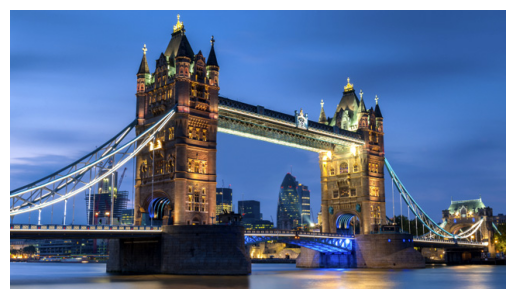

In [2]:
from PIL import Image
import matplotlib.pyplot as plt

image = Image.open("sample.jpg")
plt.imshow(image)
plt.axis("off")


## Step 2: Convert image to Base64
-----------------------

Computers don’t understand images directly.
They understand text or binary data.

So we convert image → base64 string.

In [3]:
import base64

def encode_image(path):
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode()

image_base64 = encode_image("sample.jpg")

print(image_base64);


...


Step 3: Send image to ChatGPT (LLM)
----------------------------

In [4]:
from openai import OpenAI

client = OpenAI()

response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[
        {
            "role": "user",
            "content": [
                {"type": "text", "text": "Describe this image in simple words"},
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/jpeg;base64,{image_base64}"
                    }
                }
            ]
        }
    ]
)

print(response.choices[0].message.content)


The image shows a beautiful bridge at night, called Tower Bridge, in London. The bridge is well-lit, with tall towers and lots of details. Below it, there is water reflecting the lights, and in the background, there are buildings and a clear blue sky. It looks very impressive and historic.


MODULE 2 — Visual Question Answering (Image + Question)
-------------------------------------------------------
Ask different questions on the same image

In [5]:
question = "Tell me the history of the image, associate it with the historical event and find some clues around it"

response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[
        {
            "role": "user",
            "content": [
                {"type": "text", "text": question},
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/jpeg;base64,{image_base64}"
                    }
                }
            ]
        }
    ]
)

print("Question:", question)
print("Answer:", response.choices[0].message.content)


Question: Tell me the history of the image, associate it with the historical event and find some clues around it
Answer: The structure in the image is the Tower Bridge, one of London's most iconic landmarks. Here’s a brief history and its significance:

### History of Tower Bridge

1. **Construction**: Tower Bridge was built between 1886 and 1894 to alleviate road traffic while still allowing ships to pass through the Thames. Before its construction, the only crossing downstream was London Bridge.

2. **Design**: The bridge was designed by Sir Horace Jones, and its distinctive Gothic style, featuring two towers, was meant to complement the nearby Tower of London.

3. **Engineering**: It was innovative for its time, employing a bascule (drawbridge) mechanism that allows the two halves of the roadway to lift. It still operates today, allowing larger vessels to navigate the river.

4. **Historical Significance**: The bridge has become a symbol of London and is often featured in literature

MODULE 3 — Speech to Text (Audio → Text = Transcribing)
----------------------------------------
Convert human voice into text using ChatGPT - ASR--> Automatic Speech Recognition

In [6]:
audio_file = open("speech.mp3", "rb")

transcript = client.audio.transcriptions.create(
    model="gpt-4o-transcribe",
    file=audio_file
)

print(transcript.text)


You are just a line of code.


MODULE 4 — Text to Speech (Text → Audio)
----------------------------------------

ChatGPT speaks back

In [7]:
from openai import OpenAI

client = OpenAI()

speech = client.audio.speech.create(
    model="gpt-4o-mini-tts",
    voice="nova",
    input="Welcome to Multimodal AI class. My name is Rakesh Kumar Singh and I welcome you all to this wonderful learning session where you will explore unlimited possibilities of AI."
)

with open("output.mp3", "wb") as f:
    f.write(speech.content)

print("Audio file saved as output.mp3")

Audio file saved as output.mp3


In [9]:
!pip install opencv-python pillow -q

MODULE 5 — Video Understanding (Conceptual + Simple)
----------------------------------------------------

Video

  ↓

Frames (Images)

  ↓

Image Captioning

  ↓
  
Text Summary


install --> pip install opencv-python pillow -q


In [10]:
import cv2, base64, io
from PIL import Image
from openai import OpenAI

client = OpenAI()

video = cv2.VideoCapture("Viedeo Descriptions.mp4")
descriptions = []
frame_count = 0

while video.isOpened():
    success, frame = video.read()
    if not success or len(descriptions) == 3:
        break

    if frame_count % 30 == 0: #take one frame evry 30 frames - sampling strategy
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        image = Image.fromarray(frame)

        buffer = io.BytesIO()
        image.save(buffer, format="JPEG")
        img_base64 = base64.b64encode(buffer.getvalue()).decode()

        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {
                    "role": "user",
                    "content": [
                        {"type": "text", "text": "Describe what is happening in this video frame"},
                        {
                            "type": "image_url",
                            "image_url": {
                                "url": f"data:image/jpeg;base64,{img_base64}"
                            }
                        }
                    ]
                }
            ]
        )

        descriptions.append(response.choices[0].message.content)

    frame_count += 1

video.release()

summary = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[
        {
            "role": "user",
            "content": "Summarize the video using these descriptions:\n" + "\n".join(descriptions)
        }
    ]
)

print("🎬 VIDEO SUMMARY:\n")
print(summary.choices[0].message.content)


🎬 VIDEO SUMMARY:

The video captures a basketball practice scene on an outdoor court where two individuals are engaged in drills. One player, wearing a white tank top and black shorts, is dribbling the ball in a low stance, indicating preparation for a move or pass. The second player, dressed in a black tank top and shorts, is poised defensively, ready to react. The setting features a vibrant athletic environment with green fields and sports equipment in the background, along with a tall fenced area around the court. The clear day adds to the energetic atmosphere, showcasing an active moment in their training.


Introduction to Agents (ReAct)
-----------------------------

ChatGPT can think, use tools, decide

Thought → Action → Observation → Final Answer


In [11]:
prompt = """
You are an intelligent agent.
Question: What is 15 * 4 + 10?

Think step by step.
"""

response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[{"role": "user", "content": prompt}]
)

print(response.choices[0].message.content)


To solve the expression \(15 \times 4 + 10\), follow these steps:

1. **Calculate \(15 \times 4\)**:
   \[
   15 \times 4 = 60
   \]

2. **Add 10 to the result**:
   \[
   60 + 10 = 70
   \]

So, \(15 \times 4 + 10 = 70\).


MODULE 7 — Challenges in Multimodal AI


Challenge	---->    Example
---------------------------
Hallucination:	Wrong object detection

Bias:	        Skin tone errors

Cost:	        Image/video expensive

Latency:    	Video slow


In [12]:
# MODULE 7 — Challenges in Multimodal AI

def explain_multimodal_challenges():
    challenges = {
        "Hallucination": {
            "example": "Wrong object detection",
            "description": (
                "Sometimes a multimodal AI model sees an image and identifies "
                "an object that is not actually there. This is called hallucination."
            ),
            "demo_output": "Model says: 'There is a dog in the image' but the image actually contains a cat."
        },
        "Bias": {
            "example": "Skin tone errors",
            "description": (
                "Some AI models perform better on certain skin tones, accents, "
                "or backgrounds and worse on others. This creates unfair results."
            ),
            "demo_output": "Model detects a face correctly for one skin tone but fails for another."
        },
        "Cost": {
            "example": "Image/video expensive",
            "description": (
                "Processing images and especially videos requires more compute, "
                "more memory, and more money than plain text processing."
            ),
            "demo_output": "Text request cost = low, image request cost = medium, video request cost = high."
        },
        "Latency": {
            "example": "Video slow",
            "description": (
                "Video contains many frames, so models take more time to process it. "
                "This causes slow response time."
            ),
            "demo_output": "Text response: 1 second, image response: 3 seconds, video response: 15 seconds."
        }
    }

    print("=" * 70)
    print("MODULE 7 — Challenges in Multimodal AI")
    print("=" * 70)

    for challenge, details in challenges.items():
        print(f"\nChallenge      : {challenge}")
        print(f"Example        : {details['example']}")
        print(f"Explanation    : {details['description']}")
        print(f"Demo Scenario  : {details['demo_output']}")
        print("-" * 70)


# Run the function
explain_multimodal_challenges()

MODULE 7 — Challenges in Multimodal AI

Challenge      : Hallucination
Example        : Wrong object detection
Explanation    : Sometimes a multimodal AI model sees an image and identifies an object that is not actually there. This is called hallucination.
Demo Scenario  : Model says: 'There is a dog in the image' but the image actually contains a cat.
----------------------------------------------------------------------

Challenge      : Bias
Example        : Skin tone errors
Explanation    : Some AI models perform better on certain skin tones, accents, or backgrounds and worse on others. This creates unfair results.
Demo Scenario  : Model detects a face correctly for one skin tone but fails for another.
----------------------------------------------------------------------

Challenge      : Cost
Example        : Image/video expensive
Explanation    : Processing images and especially videos requires more compute, more memory, and more money than plain text processing.
Demo Scenario  